Memulai Pelatihan Model LSTM Terbaik...
Epoch 1/50


/Users/adrinafirda/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - loss: 0.0178 - val_loss: 0.0097
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0101 - val_loss: 7.3833e-04
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0187 - val_loss: 0.0114
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0437 - val_loss: 8.0754e-04
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1077 - val_loss: 0.1226
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1410 - val_loss: 0.0539
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0563 - val_loss: 0.0161
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0418 - val_loss: 0.0154
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0967 - val_loss: 0.0424
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step



HASIL EVALUASI MODEL LSTM OPTIMAL
MAE  : 0.2912
RMSE : 0.4212
MAPE : 111.78%

Menyimpan berkas untuk kebutuhan Dashboard...
-> Model berhasil disimpan di: /Users/adrinafirda/ml/Project-Machine-Learning/models/best_lstm_model.h5
-> Scaler berhasil disimpan di: /Users/adrinafirda/ml/Project-Machine-Learning/models/forecast_scaler.pkl
-> Data visualisasi JSON berhasil disimpan di: /Users/adrinafirda/ml/Project-Machine-Learning/models/forecast_results.json


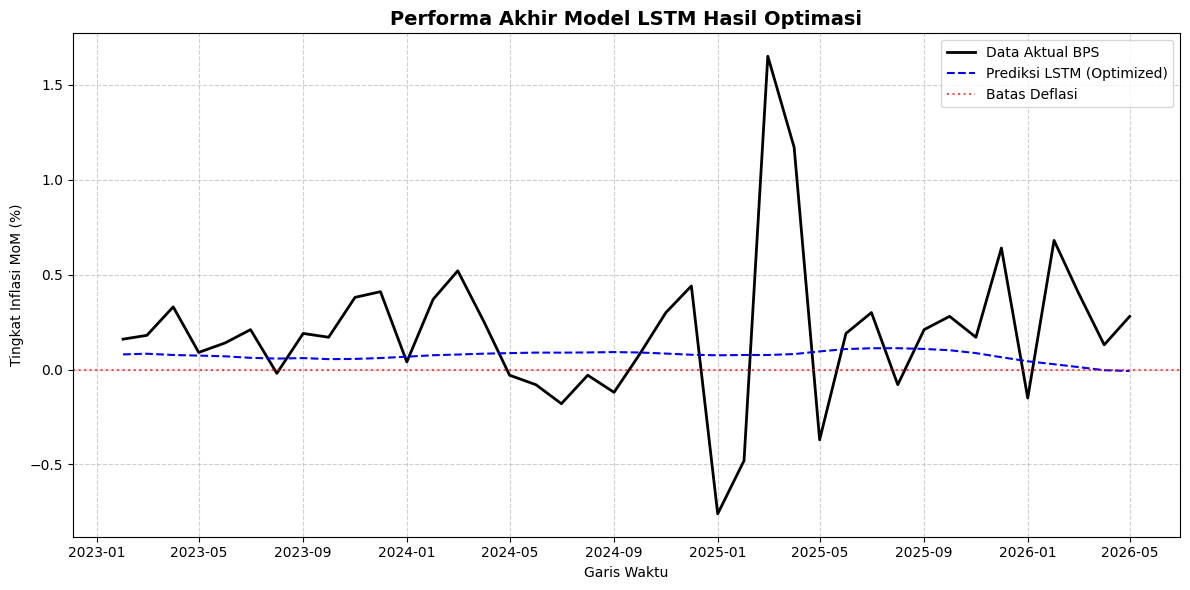

In [10]:
import os
import numpy as np
import pandas as pd
import json
import pickle
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 1. SETTING PATH & LOAD DATA
BASE_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()

# Jika file CSV ada di luar folder script, gunakan path absolut langsung:
DATA_PATH = "/Users/adrinafirda/ml/Project-Machine-Learning/datasets/processed/clean_inflasi_ts.csv"

# ATAU jika file CSV berada di dalam folder proyek Anda (disarankan):
# DATA_PATH = os.path.join(BASE_DIR, "datasets", "processed", "clean_inflasi_ts.csv")

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"File data tidak ditemukan di {DATA_PATH}. Pastikan file CSV berada di folder yang sesuai.")

df = pd.read_csv(DATA_PATH)
df['Tanggal'] = pd.to_datetime(df['Tanggal'])
df = df.sort_values('Tanggal').reset_index(drop=True)

# Mengatasi nilai NaN di awal periode secara aman (backward & forward fill)
df = df.bfill().ffill()

# 2. DEFINISI FITUR UNTUK MULTIVARIAT LSTM (Sesuai eksperimen terbaikmu)
target_col = 'Inflasi_MoM'
feature_cols = ['Inflasi_MoM', 'IHK', 'BI_Rate', 'DXY', 'Harga_Minyak_USD']

data_matrix = df[feature_cols].values
dates = df['Tanggal'].values

# Split Data secara Kronologis (80% Train, 20% Test) untuk mencegah kebocoran waktu
train_size = int(len(data_matrix) * 0.8)
train_data = data_matrix[:train_size]
test_data = data_matrix[train_size:]
test_dates = dates[train_size:]

# Scaling Fitur - Fit HANYA pada data training untuk mencegah Data Leakage
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

# 3. MEMBUAT TIMESTEPS SEQUENCE (Look-back = 12 Bulan sesuai fitur unggulanmu)
def create_dataset(dataset, look_back=12):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :]) # Mengambil semua fitur makro
        y.append(dataset[i + look_back, 0])     # Indeks 0 adalah target (Inflasi_MoM)
    return np.array(X), np.array(y)

look_back = 12
X_train, y_train = create_dataset(train_scaled, look_back)
X_test, y_test = create_dataset(test_scaled, look_back)

# 4. MEMBANGUN ARSITEKTUR LSTM TERBAIK
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(look_back, X_train.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Tambahan Early Stopping agar model berhenti melatih jika sudah konvergen (mencegah overfitting)
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

print("Memulai Pelatihan Model LSTM Terbaik...")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# 5. PREDIKSI & INVERSE TRANSFORM
predictions_scaled = model.predict(X_test)

# Membuat struktur dummy array untuk mengembalikan skala khusus kolom target
dummy_pred = np.zeros((len(predictions_scaled), len(feature_cols)))
dummy_pred[:, 0] = predictions_scaled.flatten()
predictions = scaler.inverse_transform(dummy_pred)[:, 0]

# Mengembalikan skala data aktual test
dummy_actual = np.zeros((len(y_test), len(feature_cols)))
dummy_actual[:, 0] = y_test
y_test_actual = scaler.inverse_transform(dummy_actual)[:, 0]

# Menyelaraskan tanggal untuk data hasil prediksi (dipotong periode look_back)
final_test_dates = test_dates[look_back:]

# 6. EVALUASI METRIK KINERJA
mae = mean_absolute_error(y_test_actual, predictions)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
mape = mean_absolute_percentage_error(y_test_actual, predictions)

print("\n" + "="*40)
print("HASIL EVALUASI MODEL LSTM OPTIMAL")
print("="*40)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape * 100:.2f}%")
print("="*40)

# 7. MENYIMPAN MODEL, SCALER (.PKL), & HASIL PREDIKSI JSON
print("\nMenyimpan berkas untuk kebutuhan Dashboard...")

# Path langsung ke folder models yang sudah Anda siapkan
FOLDER_MODEL = "/Users/adrinafirda/ml/Project-Machine-Learning/models"

# A. Simpan model LSTM (.h5) ke folder models
model_save_path = os.path.join(FOLDER_MODEL, "best_lstm_model.h5")
model.save(model_save_path)
print(f"-> Model berhasil disimpan di: {model_save_path}")

# B. Simpan Scaler (.pkl) ke folder models untuk normalisasi data di dashboard
scaler_save_path = os.path.join(FOLDER_MODEL, "forecast_scaler.pkl")
with open(scaler_save_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"-> Scaler berhasil disimpan di: {scaler_save_path}")

# Konversi tanggal numpy/pandas ke format string agar kompatibel dengan file JSON
tanggal_visualisasi = pd.to_datetime(final_test_dates).strftime('%Y-%m-%d').tolist()

dashboard_data = {
    "tanggal": tanggal_visualisasi,
    "aktual": y_test_actual.tolist(),       # List nilai aktual target
    "prediksi_lstm": predictions.tolist()   # List hasil prediksi LSTM
}

# C. Simpan file JSON hasil prediksi ke folder models
json_save_path = os.path.join(FOLDER_MODEL, "forecast_results.json")
with open(json_save_path, 'w') as f:
    json.dump(dashboard_data, f, indent=4)
print(f"-> Data visualisasi JSON berhasil disimpan di: {json_save_path}")



# 8. VISUALISASI EVALUASI
plt.figure(figsize=(12, 6))
plt.plot(final_test_dates, y_test_actual, label='Data Aktual BPS', color='black', linewidth=2)
plt.plot(final_test_dates, predictions, label='Prediksi LSTM (Optimized)', color='blue', linestyle='--')
plt.axhline(0, color='red', linestyle=':', alpha=0.7, label='Batas Deflasi')
plt.title("Performa Akhir Model LSTM Hasil Optimasi", fontsize=14, fontweight='bold')
plt.xlabel("Garis Waktu")
plt.ylabel("Tingkat Inflasi MoM (%)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()